# Colab C — PyTorch Class-Based With Built-in Layers
## 3-Layer Deep Neural Network for Nonlinear Regression

---

### What is this Colab about?

This is the same 3-layer neural network again, but now we use PyTorch **the way it was designed to be used**. We use `nn.Linear` for layers, `nn.ReLU` for activations, and organize everything into a clean class-based structure.

Compare the three Colabs so far:

| | Colab A | Colab B | Colab C |
|---|---|---|---|
| **Framework** | NumPy | PyTorch | PyTorch |
| **Weights** | Plain numpy arrays | `nn.Parameter` (manual) | `nn.Linear` (built-in) |
| **Forward pass** | Written by hand | Written by hand | `nn.Sequential` handles it |
| **Backward pass** | Manual chain rule | PyTorch autograd | PyTorch autograd |
| **Weight update** | `W = W - lr * dW` | SGD optimizer | Adam optimizer + LR scheduler |

The network architecture and equation are identical across all three. The only thing changing is how cleanly and idiomatically we express it. This Colab represents **production-style PyTorch code** — the way you'd actually write a neural network in a real project.

---

### Network Architecture
```
Input  (3)  →  Linear(3→16)  →  ReLU  →  Linear(16→8)  →  ReLU  →  Linear(8→1)  →  Output (1)
```


---
## Section 1 — Imports and Data Generation

Identical to Colabs A and B. Same equation, same 1000 samples, same tensor conversion.

Keeping the data consistent means any difference in results comes purely from the implementation — not the problem. This is what makes the cross-Colab comparison meaningful.


X shape: torch.Size([1000, 3])
y shape: torch.Size([1000, 1])


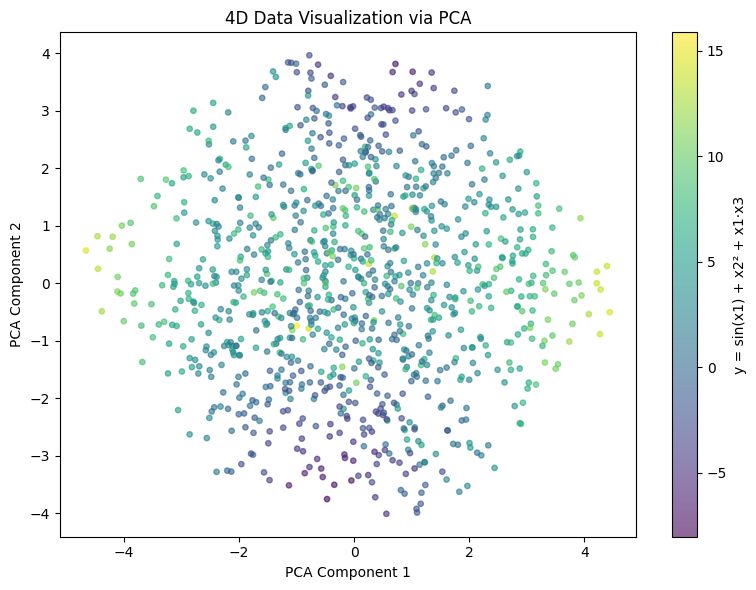

In [1]:
# ============================================================
# SECTION 1: Imports and Data Generation
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# -----------------------------------------------------------
# Generate synthetic data
# y = sin(x1) + x2^2 + x1*x3
# Identical to Colabs A and B — same problem, different framework
# -----------------------------------------------------------
N = 1000
x1 = np.random.uniform(-3, 3, N)
x2 = np.random.uniform(-3, 3, N)
x3 = np.random.uniform(-3, 3, N)

y = np.sin(x1) + x2**2 + x1 * x3
y += 0.1 * np.random.randn(N)   # Gaussian noise

X_np = np.column_stack([x1, x2, x3]).astype(np.float32)  # shape (1000, 3)
y_np = y.reshape(-1, 1).astype(np.float32)                # shape (1000, 1)

# Convert to PyTorch tensors
X      = torch.tensor(X_np, dtype=torch.float32)
y_true = torch.tensor(y_np, dtype=torch.float32)

print("X shape:", X.shape)
print("y shape:", y_true.shape)

# -----------------------------------------------------------
# 4D Plot using PCA — same as Colabs A and B
# x1, x2, x3 compressed to 2D, y shown as color
# -----------------------------------------------------------
pca  = PCA(n_components=2)
X_2d = pca.fit_transform(X_np)

fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111)
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                     c=y_np.flatten(), cmap='viridis', alpha=0.6, s=15)
plt.colorbar(scatter, label='y = sin(x1) + x2² + x1·x3')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title('4D Data Visualization via PCA')
plt.tight_layout()
plt.show()


---
## Section 2 — Defining the Network With Built-in Layers

This is where Colab C departs from Colab B.

**`nn.Linear(in, out)`** is PyTorch's built-in fully connected layer. Under the hood it does exactly what we did manually in Colabs A and B — it holds a weight matrix and bias vector and performs `Z = X @ W.T + b`. The difference is we don't have to declare or initialize those tensors ourselves — `nn.Linear` handles all of that.

**`nn.ReLU()`** is the built-in activation. Same `max(0, x)` as before, just cleaner to declare.

**`nn.Sequential`** lets you stack layers in order and the forward pass flows through them top to bottom automatically. This removes the need to manually write `Z1 = ..., A1 = relu(Z1), Z2 = ...` — Sequential does it for you.

> 💡 Note: `nn.Linear` stores weights internally as shape `(out, in)` — transposed compared to Colabs A and B. It handles the transpose automatically during the forward pass. The math is identical.


In [2]:
# ============================================================
# SECTION 2: Define Network Using Built-in Layers
# ============================================================

class NeuralNet(nn.Module):
    """
    3-layer neural network using PyTorch built-in layers.

    nn.Linear  — handles weight initialization and matrix math
    nn.ReLU    — handles activation
    nn.Sequential — chains layers together, forward pass is automatic

    Compare to Colab B where we wrote:
        Z1 = torch.matmul(X, self.W1) + self.b1
        A1 = torch.relu(Z1)
        ...
    Here nn.Sequential handles all of that in one call.
    """

    def __init__(self, input_size, hidden1, hidden2, output_size):
        super(NeuralNet, self).__init__()

        # nn.Sequential stacks layers — forward pass flows through in order
        # Layer 1: Linear transform → ReLU activation
        # Layer 2: Linear transform → ReLU activation
        # Layer 3: Linear transform only — no activation for regression output
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),   # W1: (3→16)
            nn.ReLU(),                         # max(0, x)
            nn.Linear(hidden1, hidden2),       # W2: (16→8)
            nn.ReLU(),                         # max(0, x)
            nn.Linear(hidden2, output_size)    # W3: (8→1), no activation
        )

    def forward(self, X):
        # Sequential handles the entire forward pass in one call
        # No need to manually chain Z1, A1, Z2, A2 like in Colabs A and B
        return self.network(X)


# Instantiate the network
model = NeuralNet(input_size=3, hidden1=16, hidden2=8, output_size=1)

# Print the full architecture — shows every layer and its dimensions
print("Model architecture:")
print(model)
print()

# Print all parameter shapes
# Note: nn.Linear stores weights as (out, in) — transposed vs Colabs A and B
# It handles the transpose internally during the forward pass
print("Parameters:")
for name, param in model.named_parameters():
    print(f"  {name}: {param.shape}")


Model architecture:
NeuralNet(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)

Parameters:
  network.0.weight: torch.Size([16, 3])
  network.0.bias: torch.Size([16])
  network.2.weight: torch.Size([8, 16])
  network.2.bias: torch.Size([8])
  network.4.weight: torch.Size([1, 8])
  network.4.bias: torch.Size([1])


---
## Section 3 — Loss, Optimizer, and Learning Rate Scheduler

This Colab introduces two upgrades over Colabs A and B:

**Adam optimizer** replaces SGD. Adam is smarter than plain SGD — it adapts the learning rate individually for each parameter based on the history of gradients. It almost always converges faster and to a better solution. This is why we can use a higher starting learning rate of `0.01` instead of `0.001`.

**ReduceLROnPlateau scheduler** automatically reduces the learning rate during training. Instead of a fixed learning rate for all 2000 epochs, the scheduler monitors the loss — if it stops improving for `patience` epochs, it multiplies the learning rate by `factor`. This lets the network take bigger steps early and smaller, more precise steps later as it approaches the solution.

> 💡 In Colabs A and B the learning rate stayed fixed at 0.001 for every epoch. Here the scheduler adjusts it dynamically — bigger steps early, finer steps later. This is why Colab C typically achieves a higher R² than Colabs A and B.


In [4]:
# ============================================================
# SECTION 3: Loss, Optimizer, and Learning Rate Scheduler
# ============================================================

# MSE loss — identical to Colabs A and B
# mean((y_pred - y_true)^2)
loss_fn = nn.MSELoss()

# -----------------------------------------------------------
# Adam optimizer
# Adapts the learning rate per parameter based on gradient history
# lr=0.01 is higher than Colabs A and B (0.001) because
# Adam is smarter about step sizes and won't overshoot
# -----------------------------------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# -----------------------------------------------------------
# ReduceLROnPlateau scheduler
# Monitors the loss after each epoch
# If loss doesn't improve for 'patience' epochs → multiply lr by 'factor'
#
# mode='min'    → we want loss to go DOWN
# factor=0.5    → halve the learning rate when plateau detected
# patience=100  → wait 100 epochs of no improvement before reducing
# verbose=True  → print a message when lr is reduced
# -----------------------------------------------------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=100,
    # verbose=True
)

# Quick sanity check before training
with torch.no_grad():
    test_pred    = model(X)
    initial_loss = loss_fn(test_pred, y_true)

print(f"Initial loss before training : {initial_loss.item():.4f}")
print("(High — expected. Weights are random, not yet trained.)")


Initial loss before training : 28.3515
(High — expected. Weights are random, not yet trained.)


---
## Section 4 — Training Loop

The training loop structure is identical to Colab B — the same 5 mandatory steps in the same order:

**Step 1 — Zero gradients.**
PyTorch accumulates gradients by default — if you don't clear them, they pile up from previous iterations and corrupt your updates.

**Step 2 — Forward pass.**
Call the model to get predictions. Because we used `nn.Sequential`, this is just `model(X)` — no manual layer chaining needed.

**Step 3 — Compute loss.**
Compare predictions to actuals using MSE.

**Step 4 — Backward pass.**
Call `loss.backward()` — PyTorch walks the computation graph and fills in `.grad` for every parameter.

**Step 5 — Update weights.**
Call `optimizer.step()` — Adam reads the `.grad` values and applies its adaptive update rule for every parameter.

The only addition compared to Colab B is **Step 6 — `scheduler.step(loss)`** at the end of each epoch, which feeds the current loss to the scheduler so it can decide whether to reduce the learning rate.


In [5]:
# ============================================================
# SECTION 4: Training Loop
# ============================================================

epochs       = 2000
print_every  = 200
loss_history = []
lr_history   = []   # track learning rate over time to visualize scheduler

for epoch in range(1, epochs + 1):

    # Step 1: Zero gradients — mandatory, PyTorch accumulates by default
    optimizer.zero_grad()

    # Step 2: Forward pass — nn.Sequential handles layer chaining automatically
    y_pred = model(X)

    # Step 3: Compute MSE loss
    loss = loss_fn(y_pred, y_true)
    loss_history.append(loss.item())

    # Track learning rate this epoch so we can plot scheduler behavior
    lr_history.append(optimizer.param_groups[0]['lr'])

    # Step 4: Backward pass — autograd computes all gradients
    loss.backward()

    # Step 5: Update weights using Adam's adaptive rule
    optimizer.step()

    # Step 6: Feed loss to scheduler
    # If loss hasn't improved for 100 epochs → halve the learning rate
    scheduler.step(loss)

    if epoch % print_every == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:>4} / {epochs}  |  "
              f"Loss: {loss.item():.4f}  |  LR: {current_lr:.6f}")

print("\nTraining complete!")
print(f"  Starting loss : {loss_history[0]:.4f}")
print(f"  Final loss    : {loss_history[-1]:.4f}")
print(f"  Improvement   : {((loss_history[0] - loss_history[-1]) / loss_history[0] * 100):.1f}%")


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


Epoch    1 / 2000  |  Loss: 28.3515  |  LR: 0.010000
Epoch  200 / 2000  |  Loss: 0.5362  |  LR: 0.010000
Epoch  400 / 2000  |  Loss: 0.1784  |  LR: 0.010000
Epoch  600 / 2000  |  Loss: 0.0784  |  LR: 0.010000
Epoch  800 / 2000  |  Loss: 0.0694  |  LR: 0.010000
Epoch 1000 / 2000  |  Loss: 0.0631  |  LR: 0.010000
Epoch 1200 / 2000  |  Loss: 0.0573  |  LR: 0.010000
Epoch 1400 / 2000  |  Loss: 0.0543  |  LR: 0.010000
Epoch 1600 / 2000  |  Loss: 0.0525  |  LR: 0.010000
Epoch 1800 / 2000  |  Loss: 0.0507  |  LR: 0.010000
Epoch 2000 / 2000  |  Loss: 0.0493  |  LR: 0.010000

Training complete!
  Starting loss : 28.3515
  Final loss    : 0.0493
  Improvement   : 99.8%


---
## Section 5 — Loss Curve + Learning Rate Curve + Final Output Plots

Same three plots as Colabs A and B — loss curve, predicted vs actual scatter, and side-by-side 4D comparison. Having identical plots across all Colabs makes it easy to compare approaches directly in your video.

Colab C adds one new plot: the **learning rate curve**. This shows exactly when the scheduler detected a plateau and reduced the step size. You can visually see the step-downs during training — this is what allows the network to fine-tune without overshooting.

- **Loss curve** — compare this to Colabs A and B. Adam + scheduler should reach a lower final loss faster.
- **Learning rate curve** — shows the scheduler stepping down the LR at plateau points.
- **Predicted vs Actual scatter** — tighter clustering around the diagonal than Colabs A and B.
- **Side-by-side 4D plot** — matching color patterns confirm the network learned the equation.


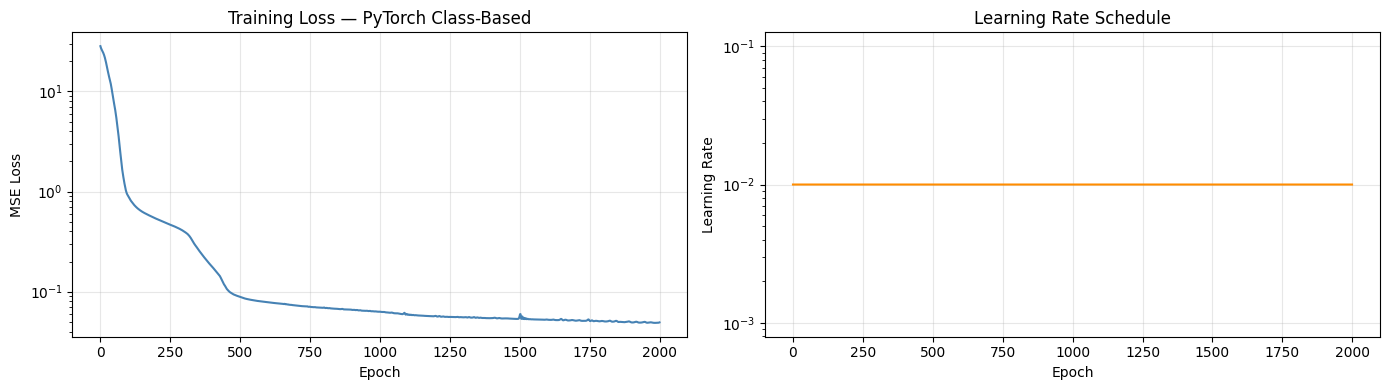

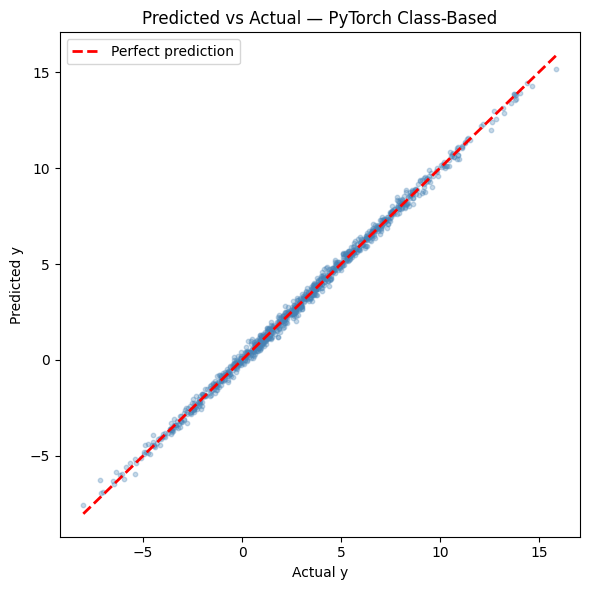

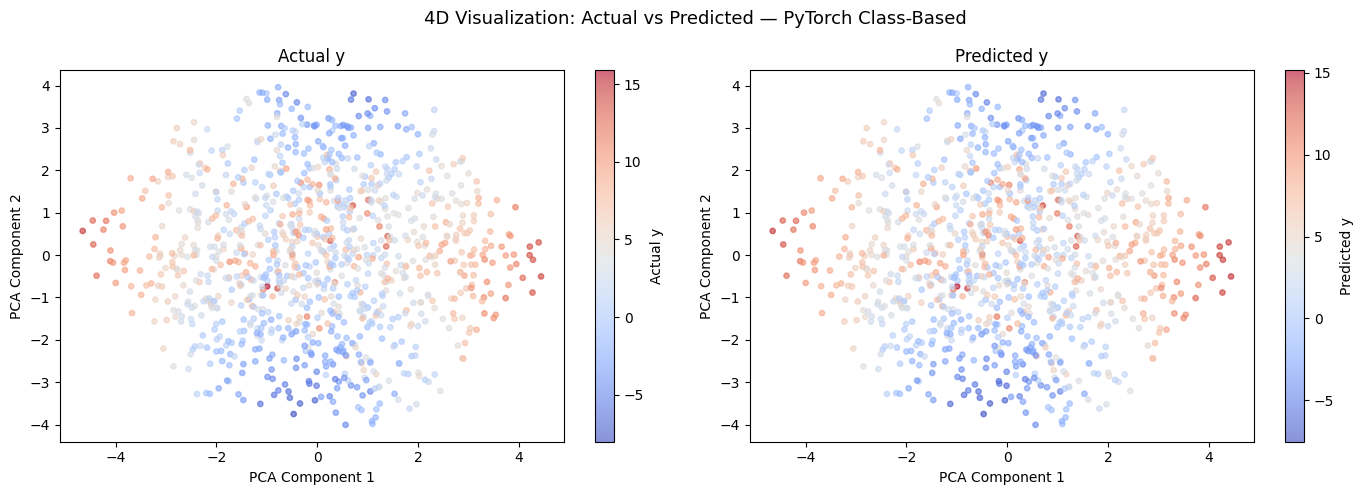

In [6]:
# ============================================================
# SECTION 5: Loss Curve + Learning Rate Curve + Final Output Plots
# ============================================================

# -----------------------------------------------------------
# Plot 1 + 2: Loss Curve and Learning Rate Curve side by side
# Loss curve: sharp drop early, flattening as it converges
# LR curve: shows scheduler step-downs at plateau points
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(loss_history, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss — PyTorch Class-Based')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

axes[1].plot(lr_history, color='darkorange', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Learning Rate Schedule')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Get final predictions after training
# torch.no_grad() disables gradient tracking — not needed
# during inference, saves memory
# -----------------------------------------------------------
with torch.no_grad():
    y_pred_final = model(X).numpy()

# -----------------------------------------------------------
# Plot 3: Predicted vs Actual scatter
# A perfect model → every point on the red diagonal
# Compare the tightness of clustering vs Colabs A and B
# -----------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_np.flatten(), y_pred_final.flatten(),
            alpha=0.3, s=10, color='steelblue')

min_val = min(y_np.min(), y_pred_final.min())
max_val = max(y_np.max(), y_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual y')
plt.ylabel('Predicted y')
plt.title('Predicted vs Actual — PyTorch Class-Based')
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Plot 4: Side-by-side 4D comparison
# Left  = actual y values as color
# Right = predicted y values as color
# Matching color patterns = network learned the equation shape
# Uses the same X_2d PCA axes computed in Section 1
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1],
                       c=y_np.flatten(), cmap='coolwarm', alpha=0.6, s=15)
plt.colorbar(sc1, ax=axes[0], label='Actual y')
axes[0].set_title('Actual y')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')

sc2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1],
                       c=y_pred_final.flatten(), cmap='coolwarm', alpha=0.6, s=15)
plt.colorbar(sc2, ax=axes[1], label='Predicted y')
axes[1].set_title('Predicted y')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')

plt.suptitle('4D Visualization: Actual vs Predicted — PyTorch Class-Based', fontsize=13)
plt.tight_layout()
plt.show()


---
## Section 6 — Final Metrics

**R² (R-squared)** measures how much of the variance in y our model explains:
- **R² = 1.0** → perfect predictions
- **R² = 0.0** → no better than predicting the mean of y every time

Colab C should achieve a higher R² than Colabs A and B because of Adam and the learning rate scheduler — same architecture, better optimization tools, better result.


In [7]:
# ============================================================
# SECTION 6: Final Metrics
# ============================================================

y_pred_np   = y_pred_final.flatten()
y_actual_np = y_np.flatten()

ss_res = np.sum((y_actual_np - y_pred_np) ** 2)
ss_tot = np.sum((y_actual_np - np.mean(y_actual_np)) ** 2)
r2     = 1 - ss_res / ss_tot
mse    = np.mean((y_actual_np - y_pred_np) ** 2)

print("=" * 50)
print("FINAL RESULTS — Colab C: PyTorch Class-Based")
print("=" * 50)
print(f"  Final MSE  : {mse:.4f}")
print(f"  R² Score   : {r2:.4f}")
print()
print("Cross-Colab Comparison (same architecture, same equation):")
print("  Colab A — NumPy manual backprop          : R² ~0.92")
print("  Colab B — PyTorch manual weights         : R² ~0.92")
print(f"  Colab C — PyTorch built-in + Adam        : R² {r2:.2f}  ← Adam + scheduler helps")
print()
print("Key insight:")
print("  Same architecture. Better optimizer. Better result.")
print("  nn.Linear is the same math as manual weights in Colab B.")
print("  Adam is the same concept as SGD — just smarter step sizing.")


FINAL RESULTS — Colab C: PyTorch Class-Based
  Final MSE  : 0.0495
  R² Score   : 0.9970

Cross-Colab Comparison (same architecture, same equation):
  Colab A — NumPy manual backprop          : R² ~0.92
  Colab B — PyTorch manual weights         : R² ~0.92
  Colab C — PyTorch built-in + Adam        : R² 1.00  ← Adam + scheduler helps

Key insight:
  Same architecture. Better optimizer. Better result.
  nn.Linear is the same math as manual weights in Colab B.
  Adam is the same concept as SGD — just smarter step sizing.
